In [13]:
import torch
from transformers import pipeline

device_id = 0 if torch.cuda.is_available() else -1
print("Monolingual models:")
#our model
print("Downloading our model (marinaza/ru_toxic_bert)")
my_classifier = pipeline(
    "text-classification",
    model="marinaza/ru_toxic_bert",
    tokenizer="marinaza/ru_toxic_bert",
    device=device_id
)
print("Our model successfully downloaded")

#snlp model
print("Downloading baseline model (s-nlp/russian_toxicity_classifier)")
snlp_classifier = pipeline(
    "text-classification",
    model="s-nlp/russian_toxicity_classifier",
    tokenizer="s-nlp/russian_toxicity_classifier",
    device=device_id
)
print("SNLP Model successfully downloaded")

print('\n\n\n')
print("Multilingual Models:")
#multilingual bert
print("Downloading multilingual BERT toxicity classifier (FredZhang7/one-for-all-toxicity-v3)")
fredzhang_classifier = pipeline(
    "text-classification",
    model="FredZhang7/one-for-all-toxicity-v3",
    tokenizer="FredZhang7/one-for-all-toxicity-v3",
    device=device_id
)
print("Multilingual BERT model (FredZhang7) successfully downloaded")

from transformers import AutoTokenizer,AutoModel

print("Downloading multilingual toxicity classifier (textdetox/xlmr-large-toxicity-classifier-v2)")
textdetox_classifier = pipeline(
    "text-classification",
    model='textdetox/xlmr-large-toxicity-classifier-v2',
    tokenizer='textdetox/xlmr-large-toxicity-classifier-v2',
    device=device_id
)
print("Multilingual model (textdetox/xlmr-large-toxicity-classifier-v2) successfully downloaded")


print("Downloading our fine-tuned XLM-RoBERTa model")
our_xlm_classifier = pipeline(
    "text-classification",
    model="marinaza/xlm-roberta-large-toxic",
    tokenizer="marinaza/xlm-roberta-large-toxic",
    device=device_id
)
print("Our XLM-RoBERTa successfully downloaded")


print("Downloading our fine-tuned on augmented data XLM-RoBERTa model")
our_augmented_xlm_classifier = pipeline(
    "text-classification",
    model="marinaza/xlm-roberta-large-toxic_on_augmented_data",
    tokenizer="marinaza/xlm-roberta-large-toxic_on_augmented_data",
    device=device_id
)
print("Our augmented XLM-RoBERTa successfully downloaded")


print("Downloading multilingual toxicity classifier (intfloat/multilingual-e5-base)")
tokenizer = AutoTokenizer.from_pretrained('intfloat/multilingual-e5-base')
intfloat_classifier = AutoModel.from_pretrained('intfloat/multilingual-e5-base')
print("Multilingual model (intfloat/multilingual-e5-base) successfully downloaded")


Monolingual models:


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 14691.98it/s]


Our model successfully downloaded


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 12730.36it/s]


SNLP Model successfully downloaded




Multilingual Models:


...

Our XLM-RoBERTa successfully downloaded


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 16608.85it/s]


Our augmented XLM-RoBERTa successfully downloaded


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13157.82it/s]

Multilingual model (intfloat/multilingual-e5-base) successfully downloaded


In [14]:
import pandas as pd

#data preparation
ru_testset_path = '../data/raw/ru/ru_testset.csv'

ru_testset = pd.read_csv(ru_testset_path)



if 'comment' in ru_testset.columns and 'toxic' in ru_testset.columns:
    ru_testset = ru_testset.rename(columns={'comment': 'text', 'toxic': 'label'})
ru_testset = ru_testset.sample(n=1000, random_state=42).reset_index(drop=True)

print(f"Test set size (ru_testset): {len(ru_testset)} rows.")

display(ru_testset.head(10))

Test set size (ru_testset): 1000 rows.


,text,label
0,blаскеd еи кер в молодая и красивая чемпионка ...,0
1,это белый нигер(пидорашка) они в красной книге\n,1
2,👍👍👍молодцы!!!!,0
3,"сашок пзьдец, позорище проебал последний бой!!...",1
4,шиза петух че молчишь .пизду нюхаешь дочи,1
5,прочитала о вреде алкоголя и курения всё с пон...,0
6,..так как звать и место рождения..?!,0
7,считают. надо указывать. у меня тоже отказ был...,0
8,женщина вам нужно сидеть дома возле детей возл...,1
9,продажная сволочь!,1


In [15]:
import pandas as pd

multi_testset_path = '../data/processed/textdetox_multilingual_en_ru_hi_sample_504.csv'
df_multi_test = pd.read_csv(multi_testset_path)


texts_multi = df_multi_test['text'].tolist()
true_labels_multi = df_multi_test['toxic'].tolist()
languages_multi = df_multi_test['language'].tolist()

print(f"In multilingual testset {len(texts_multi)} samples.")
print(f"Separate languages: {df_multi_test['language'].value_counts().to_dict()}")


In multilingual testset 504 samples.
Separate languages: {'ru': 168, 'hi': 168, 'en': 168}


In [16]:
import json
import pandas as pd
import os
import re

#creating a bad word dictionary for keyword-based classifier
master_bad_words = set()

#extract bad word from json
print("Reading JSON")
try:
    with open('./nlp/bad_words_1.json', 'r', encoding='utf-8') as f:
        data = json.load(f)
        if 'stemmed_words' in data:
            master_bad_words.update(data['stemmed_words'])
except Exception as e:
    print(f"Could not read JSON: {e}")

#extract bad words from csv
print("Reading CSV")
try:
    df = pd.read_csv('./nlp/bad_words_2.csv', header=None)
    csv_words = df[0].dropna().astype(str).str.lower().str.strip().tolist()
    master_bad_words.update(csv_words)
except Exception as e:
    print(f"Could not read CSV: {e}")


#extract bad words from ts files
print("Reading TypeScript (.ts) files")
root_dir = './nlp/bad_words_3'
pattern = re.compile(r"'\s*([^']+?)\s*'")

if os.path.exists(root_dir):
    for subdir, dirs, files in os.walk(root_dir):
        for file in files:
            if file.endswith('.ts'):
                with open(os.path.join(subdir, file), 'r', encoding='utf-8') as f:
                    content = f.read()
                    forms = pattern.findall(content)
                    master_bad_words.update(forms)
else:
    print(f"Folder {root_dir} not found. Skipping TS files")


final_cleaned_words = {word.lower().strip() for word in master_bad_words if word.strip()}

output_filename = 'final_toxic_dictionary.json'
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(list(final_cleaned_words), f, ensure_ascii=False, indent=4)

print(f"Successfully merged {len(final_cleaned_words)} unique toxic words/forms")
print(f"Saved to: {output_filename}")

Reading JSON
Could not read JSON: [Errno 2] No such file or directory: './nlp/bad_words_1.json'
Reading CSV
Could not read CSV: [Errno 2] No such file or directory: './nlp/bad_words_2.csv'
Reading TypeScript (.ts) files
Folder ./nlp/bad_words_3 not found. Skipping TS files
Successfully merged 0 unique toxic words/forms
Saved to: final_toxic_dictionary.json


In [17]:
import json
import re
import pandas as pd

class KeywordToxicClassifier:
    def __init__(self, dictionary_path):
        """
        Initializes the classifier and loads the toxic words dictionary.
        """
        try:
            with open(dictionary_path, 'r', encoding='utf-8') as f:
                self.toxic_words = set(json.load(f))
        except FileNotFoundError:
            print(f"Error: File {dictionary_path} not found")
            self.toxic_words = set()

    def predict_text(self, text):
        """
        Checks a single text for toxic words.
        Returns 1 (toxic) or 0 (normal).
        """
        if not isinstance(text, str):
            # protection against empty values (NaN)
            return 0

        text = text.lower()

        # extract only words, ignoring punctuation (commas, dots)
        # \w+ matches all continuous sequences of word characters
        words_in_text = re.findall(r'\w+', text)


        for word in words_in_text:
            if word in self.toxic_words:
                return 1 # found a match ->  return 1 (toxic)

        return 0 # no matches found -> return 0 (normal)

    def predict_dataset(self, texts_series):
        """
        Helper function to predict an entire DataFrame column (Pandas Series).
        """
        return texts_series.apply(self.predict_text)



In [18]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


texts_ru = ru_testset['text'].tolist()
true_labels_ru = ru_testset['label'].tolist()



print("1: Our model classifies")
my_preds_raw = my_classifier(texts_ru, batch_size=32, truncation=True, max_length=128)
my_preds = [1 if p['label'] == 'toxic' else 0 for p in my_preds_raw]



1: Our model classifies


In [19]:
print("2: SNLP model classifies")
snlp_preds_raw = snlp_classifier(texts_ru, batch_size=32, truncation=True, max_length=128)
snlp_preds = [1 if p['label'].lower() == 'toxic' else 0 for p in snlp_preds_raw]


2: SNLP model classifies


In [20]:
print("3: Multilingual BERT model (FredZhang7) classifies...")

fredzhang_preds_raw = fredzhang_classifier(texts_multi, batch_size=32, truncation=True, max_length=128)
fredzhang_preds = [1 if p['label'].lower() in ['toxic', 'label_1'] else 0 for p in fredzhang_preds_raw]



3: Multilingual BERT model (FredZhang7) classifies...


In [21]:
print("4: Keyword-based classifier classifies")
keyword_classifier_model = KeywordToxicClassifier('final_toxic_dictionary.json')
keyword_preds = ru_testset['text'].apply(keyword_classifier_model.predict_text).tolist()



4: Keyword-based classifier classifies


In [22]:
print("5: Textdetoxt classifier classifies")

textdetox_preds_raw = textdetox_classifier(texts_multi, batch_size=32, truncation=True, max_length=128)
textdetox_preds = [1 if p['label'].lower() in ['toxic', 'label_1'] else 0 for p in textdetox_preds_raw]



5: Textdetoxt classifier classifies


In [23]:
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression

#6: E5 (Embeddings) + Logistic Regression classifies

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Device: {device}")

e5_model = intfloat_classifier.to(device)
e5_model.eval()


def get_e5_embeddings(text_list, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(text_list), batch_size), desc="Extract vectors"):
        batch_texts = text_list[i:i + batch_size]


        encoded_input = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        ).to(device)


        with torch.no_grad():
            model_output = e5_model(**encoded_input)


        batch_embeddings = model_output[0][:, 0, :].cpu().numpy()
        embeddings.extend(batch_embeddings)

    return np.array(embeddings)





train_data_path = '../data/processed/train_en_hi_ru_12349.csv'
df_train = pd.read_csv(train_data_path)

train_texts = df_train['text'].tolist()
train_labels = df_train['label'].tolist()


X_train = get_e5_embeddings(train_texts)
y_train = train_labels

print("train log regression")
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)




X_test = get_e5_embeddings(texts_multi)

print("6: E5 (Embeddings) + Logistic Regression classifies")
e5_preds = clf.predict(X_test).tolist()


Device: mps


Extract vectors: 100%|██████████| 386/386 [09:27<00:00,  1.47s/it]


train log regression


Extract vectors: 100%|██████████| 16/16 [00:15<00:00,  1.01it/s]

6: E5 (Embeddings) + Logistic Regression classifies


In [24]:
print("7: Our finetuned XLM-RoBERTa model classifies")

our_xlm_preds_raw = our_xlm_classifier(texts_multi, batch_size=32, truncation=True, max_length=128)
our_xlm_preds = [1 if p['label'].lower() == 'toxic' else 0 for p in our_xlm_preds_raw]



7: Our finetuned XLM-RoBERTa model classifies


In [25]:
print("8: Our finetuned on augmented data XLM-RoBERTa model classifies")

our_augmented_xlm_preds_raw = our_augmented_xlm_classifier(texts_multi, batch_size=32, truncation=True, max_length=128)
our_augmented_xlm_preds = [1 if p['label'].lower() == 'toxic' else 0 for p in our_xlm_preds_raw]


8: Our finetuned on augmented data XLM-RoBERTa model classifies


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from IPython.display import display


lang_ru = ['ru'] * len(true_labels_ru)


models_predictions = {
    #monolingual ru
    "Our Model (ru_toxic_bert)": (my_preds, true_labels_ru, lang_ru),
    "SNLP (RU Baseline)": (snlp_preds, true_labels_ru, lang_ru),
    "Keyword-based (Lexical)": (keyword_preds, true_labels_ru, lang_ru),

    #multilingual ru en hi
    "Multi BERT (FredZhang7)": (fredzhang_preds, true_labels_multi, languages_multi),
    "TextDetox (xlmr-large)": (textdetox_preds, true_labels_multi, languages_multi),
    "Our finetuned XLM-RoBERTa": (our_xlm_preds, true_labels_multi, languages_multi),
    "Our finetuned on augmented data XLM-RoBERTa": (our_augmented_xlm_preds, true_labels_multi, languages_multi),
    "Multi-E5-Base (Embeddings)": (e5_preds, true_labels_multi, languages_multi)
}



In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


for model_name, (y_pred, y_true, y_lang) in models_predictions.items():
    print(f"\n{'='*50}")
    print(f"Metrics for: {model_name}")
    print(f"{'='*50}")


    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("Macro-F1:", f1_score(y_true, y_pred, average="macro"))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification report:")
    print(classification_report(y_true, y_pred))


Metrics for: Our Model (ru_toxic_bert)
Accuracy: 0.965
Precision: 0.9698795180722891
Recall: 0.9602385685884692
Macro-F1: 0.964999964999965

Confusion matrix:
[[482  15]
 [ 20 483]]

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       497
           1       0.97      0.96      0.97       503

    accuracy                           0.96      1000
   macro avg       0.97      0.97      0.96      1000
weighted avg       0.97      0.96      0.97      1000


Metrics for: SNLP (RU Baseline)
Accuracy: 0.972
Precision: 1.0
Recall: 0.9443339960238568
Macro-F1: 0.9719864414376558

Confusion matrix:
[[497   0]
 [ 28 475]]

Classification report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       497
           1       1.00      0.94      0.97       503

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted

/Users/marinazaspa/Desktop/nlp_prakt/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/marinazaspa/Desktop/nlp_prakt/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/marinazaspa/Desktop/nlp_prakt/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

General metrics


,Macro-F1 (Main),Accuracy,Precision (Toxic),Recall (Toxic)
TextDetox (xlmr-large),0.9841,0.9841,0.9919,0.9762
SNLP (RU Baseline),0.9720,0.9720,1.0000,0.9443
Our Model (ru_toxic_bert),0.9650,0.9650,0.9699,0.9602
Our finetuned XLM-RoBERTa,0.9246,0.9246,0.9458,0.9008
Our finetuned on augmented data XLM-RoBERTa,0.9246,0.9246,0.9458,0.9008
Multi-E5-Base (Embeddings),0.8609,0.8611,0.8922,0.8214
Multi BERT (FredZhang7),0.7203,0.7341,0.9214,0.5119
Keyword-based (Lexical),0.3320,0.4970,0.0000,0.0000



 Per language Macro-F1


,Macro-F1 (EN),Macro-F1 (HI),Macro-F1 (RU)
TextDetox (xlmr-large),0.9821,0.9762,0.9940
SNLP (RU Baseline),-,-,0.9720
Our Model (ru_toxic_bert),-,-,0.9650
Our finetuned XLM-RoBERTa,0.9702,0.8617,0.9405
Our finetuned on augmented data XLM-RoBERTa,0.9702,0.8617,0.9405
Multi-E5-Base (Embeddings),0.9345,0.7513,0.8928
Multi BERT (FredZhang7),0.6952,0.5450,0.8749
Keyword-based (Lexical),-,-,0.3320



 Confusion matrices


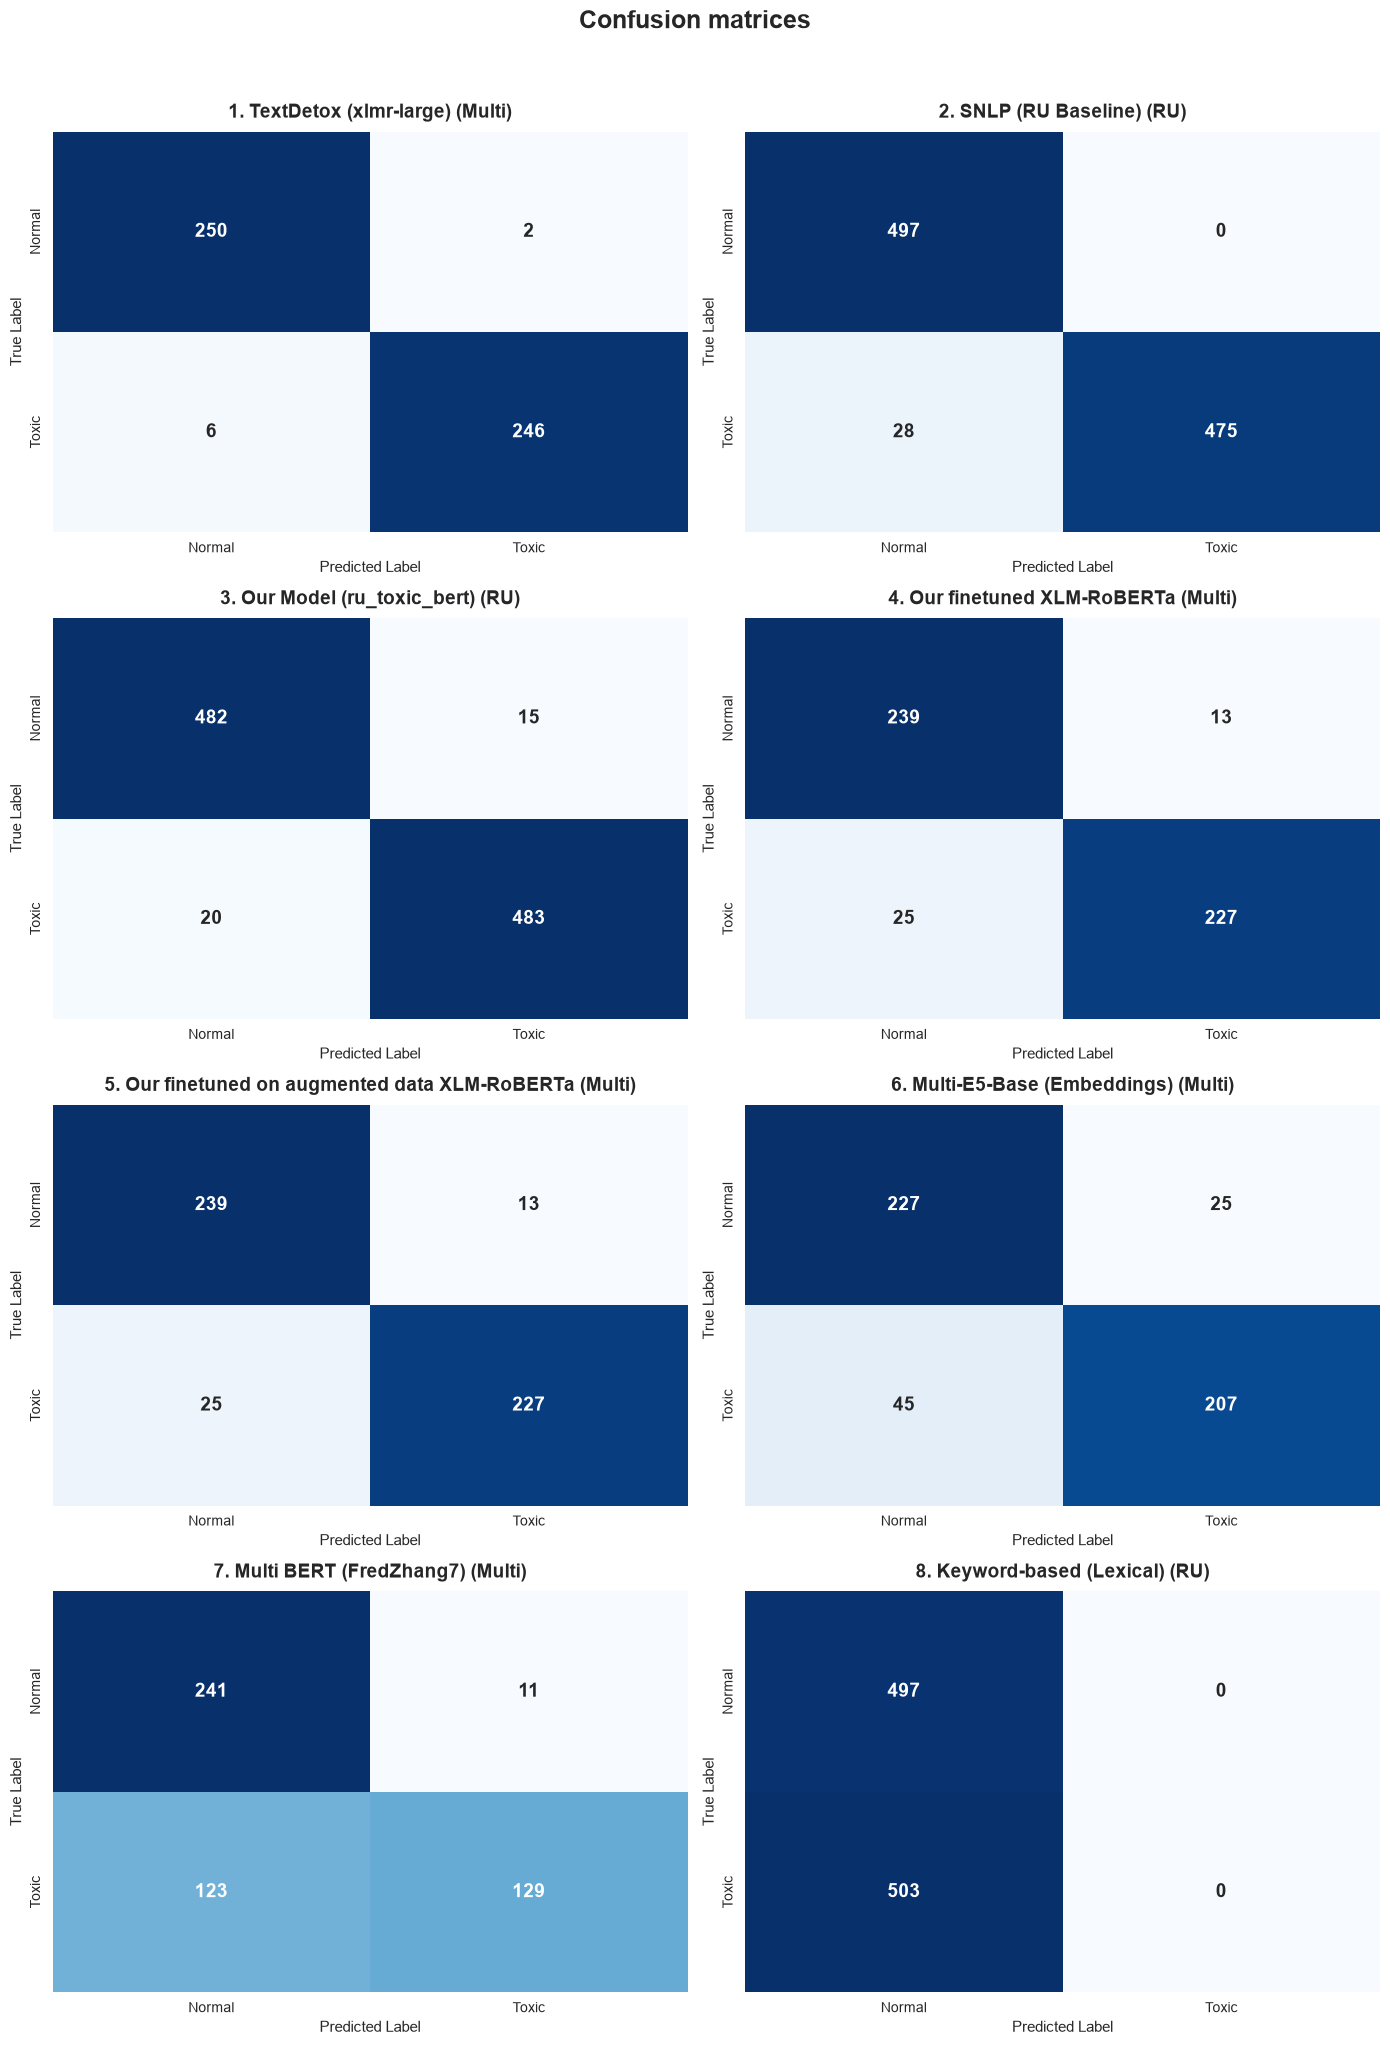

In [28]:
overall_results = {}
per_lang_f1 = {}

all_unique_languages = np.unique(lang_ru + languages_multi)


#calculation metrics
for model_name, (y_pred, y_true, y_lang) in models_predictions.items():
    #general metrics
    overall_results[model_name] = {
        "Macro-F1 (Main)": f1_score(y_true, y_pred, average='macro', zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Toxic)": precision_score(y_true, y_pred, zero_division=0),
        "Recall (Toxic)": recall_score(y_true, y_pred, zero_division=0)
    }

    # f1 per language
    for lang in all_unique_languages:
        lang_indices = [i for i, l in enumerate(y_lang) if l == lang]

        lang_key = f"Macro-F1 ({str(lang).upper()})"
        if lang_key not in per_lang_f1:
            per_lang_f1[lang_key] = {}

        if len(lang_indices) > 0:
            y_true_lang = [y_true[i] for i in lang_indices]
            y_pred_lang = [y_pred[i] for i in lang_indices]
            lang_f1 = f1_score(y_true_lang, y_pred_lang, average='macro', zero_division=0)
            per_lang_f1[lang_key][model_name] = lang_f1
        else:
            # for monolingual models
            per_lang_f1[lang_key][model_name] = np.nan


#output results
print("General metrics")
df_comparison = pd.DataFrame(overall_results).T
df_comparison = df_comparison.sort_values(by="Macro-F1 (Main)", ascending=False)

styled_comparison = df_comparison.style.highlight_max(color='#d4edda', axis=0) \
    .format("{:.4f}") \
    .set_properties(**{'border': '1px solid black', 'text-align': 'center'})

display(styled_comparison)

print("\n Per language Macro-F1")
df_lang_comparison = pd.DataFrame(per_lang_f1)
df_lang_comparison = df_lang_comparison.reindex(df_comparison.index)


styled_lang = df_lang_comparison.style.background_gradient(cmap='Blues', axis=0, vmin=0, vmax=1) \
    .format("{:.4f}", na_rep="-") \
    .set_properties(**{'border': '1px solid black', 'text-align': 'center'})

display(styled_lang)



print("\n Confusion matrices")
n_models = len(models_predictions)
cols = 2
rows = (n_models + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
fig.suptitle("Confusion matrices", fontsize=18, fontweight='bold', y=1.02)
axes = axes.ravel()

sorted_models = df_comparison.index.tolist()

for idx, model_name in enumerate(sorted_models):
    y_pred, y_true, _ = models_predictions[model_name]
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Normal', 'Toxic'],
        yticklabels=['Normal', 'Toxic'],
        ax=axes[idx],
        cbar=False,
        annot_kws={"size": 14, "weight": "bold"}
    )

    dataset_name = "RU" if "Baseline" in model_name or "Lexical" in model_name or "ru_toxic_bert" in model_name else "Multi"
    axes[idx].set_title(f"{idx + 1}. {model_name} ({dataset_name})", fontsize=14, fontweight='bold', pad=10)
    axes[idx].set_xlabel("Predicted Label", fontsize=11)
    axes[idx].set_ylabel("True Label", fontsize=11)

for i in range(n_models, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()